# Análisis de vuelos

Esta es la continuación del notebook 02_limpieza_transformacion_final.ipynb (versión en español).

Es necesario utilizar el dataset que se obtuvo anteriormente (`vuelos_historicos_consolidado.parquet`) para utilizar este cuaderno.
_____

# EDA - Análisis exploratorio de datos


En este reporte vamos a realizar un análisis univariado y bivariado, como comparar entre las dos empresas Jetsmart y Flybondi la relación entre demoras, cantidad de vuelos, que empresa es la más eficiente.

## Constantes

In [1]:
mapeo_nombres = {
    'FO': 'Flybondi',
    'WJ': 'Jetsmart'
}

# Colores que representan a cada empresa
colores_fijos = {
    'Jetsmart': '#1b365d',  # Azul
    'Flybondi': '#fdbe15'   # Amarillo
}

meses_ordenados = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

color_general = "#fc7753"
paleta = ["#fc7753", "#66d7d1", "#C45BAA"]

etiquetas_cancelado = ["No Cancelado", "Cancelado"]


## Librerías y Funciones auxiliares

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


def cargar_datos(file_path, **kwargs):
    """
    Carga un archivo CSV o Parquet y devuelve un DataFrame de pandas.

    :param file_path: Ruta al archivo.
    :param kwargs: Argumentos adicionales para pd.read_csv / pd.read_parquet.
    :return: DataFrame cargado.
    :raises ValueError: Si la extensión no es .csv ni .parquet.
    :raises RuntimeError: Si el archivo no se puede leer por otro motivo.
    """
    _, extension_archivo = os.path.splitext(file_path)
    extension_archivo = extension_archivo.lower()

    if extension_archivo == ".csv":
        lector = pd.read_csv
    elif extension_archivo == ".parquet":
        lector = pd.read_parquet
    else:
        raise ValueError(f"Formato no soportado: {extension_archivo}. Usá CSV o Parquet.")

    try:
        return lector(file_path, **kwargs)
    except Exception as e:
        raise RuntimeError(f"Error al cargar el archivo '{file_path}': {e}") from e


def graficar_frecuencias(df: pd.DataFrame, columna_frecuencia: str, categoria: str = None, titulo: str = None,
                          color: str = "green", ordenar_por_indice: bool = False, mostrar_media: bool = False,
                          colores_fijos: dict = None) -> None:
    """
    Genera un gráfico de barras de frecuencias, con una línea opcional de media.

    Parameters
    ----------
    df                : DataFrame de entrada.
    columna_frecuencia: Columna a contar en el eje X.
    categoria         : Columna opcional para agrupar por color (hue).
    titulo            : Título del gráfico. Se genera automáticamente si es None.
    color             : Color de las barras cuando no se usa categoría.
    ordenar_por_indice: Si es True, ordena el eje X por valor en vez de por frecuencia.
    mostrar_media     : Si es True, dibuja una línea horizontal con la media.
    colores_fijos     : Diccionario de colores fijos por valor de categoría.
    """
    df_plot = df.copy()

    if categoria:
        df_plot["empresa"] = df_plot["empresa"].map(mapeo_nombres).fillna(df_plot["empresa"])

    # 1. Orden del eje X
    orden = (
        sorted(df_plot[columna_frecuencia].unique()) if ordenar_por_indice
        else df_plot[columna_frecuencia].value_counts().index.astype(str)
    )

    # 2. Construcción del gráfico
    plt.figure(figsize=(10, 6))

    if categoria:
        ax = sns.countplot(data=df_plot, x=columna_frecuencia, hue=categoria, order=orden, palette=colores_fijos)
        plt.legend(title=categoria, bbox_to_anchor=(1.05, 1), loc="upper left")
    else:
        ax = sns.countplot(data=df_plot, x=columna_frecuencia, order=orden, color=color)

    # 3. Línea de media
    if mostrar_media:
        conteos = df_plot[columna_frecuencia].value_counts()
        valor_medio = conteos.mean()
        plt.axhline(valor_medio, color="red", linestyle="--", linewidth=2, label=f"Media: {valor_medio:.1f}")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    # 4. Estilo
    titulo_auto = f"Distribución de {columna_frecuencia}" + (f" por {categoria}" if categoria else "")
    plt.title(titulo or titulo_auto, fontsize=14)
    plt.xlabel(columna_frecuencia, fontsize=12)
    plt.ylabel("Cantidad de registros", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


def graficar_evolucion(df: pd.DataFrame, x: str, y: str, categoria: str = None, estimador: str = "mean",
                        titulo: str = None, colores_fijos: dict = None) -> None:
    """
    Grafica la evolución de una métrica a lo largo del tiempo o de un eje ordenado.

    Parameters
    ----------
    df           : DataFrame de entrada.
    x            : Columna para el eje X.
    y            : Columna para el eje Y (métrica).
    categoria    : Columna opcional para agrupar por color (hue).
    estimador    : Función de agregación ('mean', 'sum', 'median').
    titulo       : Título del gráfico. Se genera automáticamente si es None.
    colores_fijos: Diccionario de colores fijos por valor de categoría.
    """
    df_plot = df.copy()

    if categoria:
        df_plot[categoria] = df_plot[categoria].map(mapeo_nombres).fillna(df_plot[categoria])

    etiqueta_y = y.replace("_", " ").title()
    etiqueta_x = x.replace("_", " ").title()

    plt.figure(figsize=(12, 5))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=df_plot, x=x, y=y, hue=categoria, estimator=estimador, marker="o", linewidth=2.5,
        errorbar=None, palette=colores_fijos if categoria else None
    )

    plt.title(titulo or f"{etiqueta_y} por {etiqueta_x}", fontsize=15, pad=20)
    plt.xlabel(etiqueta_x, fontsize=12)
    plt.ylabel(f"{estimador.capitalize()} de {etiqueta_y}", fontsize=12)

    if categoria:
        plt.legend(title=categoria.replace("_", " ").title(), bbox_to_anchor=(1.05, 1), loc="upper left")

    if df_plot[x].dtype in ["int64", "int32"]:
        plt.xticks(sorted(df_plot[x].unique()))

    plt.tight_layout()
    plt.show()


def mostrar_distribucion_violin(df, columna, valor_minimo=None, paleta=None, color=color_general):
    """
    Muestra un violin plot de la distribución de una columna numérica.

    :param df: DataFrame.
    :param columna: Nombre de la columna a graficar.
    :param valor_minimo: Valor mínimo para filtrar (opcional).
    :param paleta: Nombre de paleta (ej. 'viridis', 'magma') o lista de colores.
    :param color: Color único para el violín (ej. 'skyblue').
    """
    datos_plot = df.copy()
    if valor_minimo is not None:
        datos_plot = datos_plot[datos_plot[columna] > valor_minimo]

    plt.figure(figsize=(10, 6))

    sns.violinplot(
        data=datos_plot,
        x=columna,
        inner_kws=dict(box_width=15, whis_width=2, color=".8"),
        palette=paleta,
        color=color
    )

    plt.title(f"Distribución de {columna.replace('_', ' ').title()}")
    plt.show()


def mostrar_torta_personalizada(df: pd.DataFrame, nombre_columna: str, etiquetas: list = None, titulo: str = None,
                                 colores: list = None) -> None:
    """
    Genera un gráfico de torta para una columna categórica.

    Parameters
    ----------
    df            : DataFrame de entrada.
    nombre_columna: Columna a contar y graficar.
    etiquetas     : Lista opcional de etiquetas a mostrar. Usa los valores del índice si es None.
    titulo        : Título del gráfico. Se genera automáticamente si es None.
    colores       : Lista de colores. Usa el colormap Pastel1 si es None.
    """
    datos = df[nombre_columna].value_counts()
    n_categorias = len(datos)

    # Manejo de etiquetas
    if etiquetas is None:
        etiquetas = [f"{idx} ({val})" for idx, val in zip(datos.index, datos.values)]
    else:
        etiquetas = [f"{etq} ({val})" for etq, val in zip(etiquetas, datos.values)]

    # Colores y explode
    if colores is None:
        colores = plt.cm.Pastel1.colors
    explode = [0.1 if i == 1 else 0 for i in range(n_categorias)]

    plt.figure(figsize=(8, 6))
    plt.pie(datos, labels=etiquetas, autopct="%1.1f%%", startangle=140, colors=colores[:n_categorias],
            explode=explode if n_categorias > 1 else None, shadow=True)
    plt.title(titulo if titulo else f"Distribución de {nombre_columna}", fontsize=14)
    plt.axis("equal")
    plt.show()


def graficar_impacto_temporal(df: pd.DataFrame, columna_x: str = "mes", columna_valor: str = "minutos_netos_demora",
                               categoria: str = "empresa", unidad: str = "days", mostrar_etiquetas: bool = False,
                               titulo: str = None) -> None:
    """Grafica el impacto acumulado de las demoras (en minutos/horas/días) por mes y por empresa."""

    config_unidad = {
        "minutes": {"divisor": 1,    "etiqueta": "Minutos totales", "fmt": "%.0f"},
        "hours":   {"divisor": 60,   "etiqueta": "Horas totales",   "fmt": "%.1f"},
        "days":    {"divisor": 1440, "etiqueta": "Días de demora",  "fmt": "%.2f"},
    }

    if unidad not in config_unidad:
        raise ValueError(f"unidad debe ser una de: {list(config_unidad.keys())}")

    divisor = config_unidad[unidad]["divisor"]
    etiqueta_y = config_unidad[unidad]["etiqueta"]
    fmt = config_unidad[unidad]["fmt"]

    df_plot = df.copy()

    colores_paleta = paleta
    if categoria == "empresa":
        df_plot[categoria] = df_plot[categoria].map(mapeo_nombres).fillna(df_plot[categoria])
        colores_paleta = colores_fijos

    columnas_grupo = [columna_x, categoria] if categoria else [columna_x]
    df_agrupado = df_plot.groupby(columnas_grupo)[columna_valor].sum().reset_index()
    df_agrupado["valor_convertido"] = df_agrupado[columna_valor] / divisor

    # Título automático si no se pasa uno
    etiqueta_x = columna_x.replace("_", " ").title()
    etiqueta_categoria = categoria.replace("_", " ").title() if categoria else None

    titulo_auto = (
        f"{etiqueta_y} por {etiqueta_x} y {etiqueta_categoria}"
        if etiqueta_categoria
        else f"{etiqueta_y} por {etiqueta_x}"
    )
    titulo_final = titulo if titulo else titulo_auto

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(
        data=df_agrupado,
        x=columna_x,
        y="valor_convertido",
        hue=categoria,
        palette=colores_paleta
    )

    if mostrar_etiquetas:
        for container in ax.containers:
            ax.bar_label(container, fmt=fmt, padding=3, fontsize=9)

    plt.title(titulo_final, fontsize=15, pad=20)
    plt.ylabel(etiqueta_y, fontsize=12)
    plt.xlabel(etiqueta_x, fontsize=12)

    if categoria:
        titulo_leyenda = etiqueta_categoria or categoria
        plt.legend(title=titulo_leyenda, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.margins(y=0.15)
    plt.tight_layout()
    plt.show()


def graficar_cancelaciones(df: pd.DataFrame, color: str = "steelblue", por_empresa: bool = False,
                            mes: int = None) -> None:
    """Grafica la evolución diaria de cancelaciones, opcionalmente filtrada por mes y separada por empresa."""

    df_plot = df.copy()
    df_plot["fecha"] = pd.to_datetime(df_plot["fecha"])

    if por_empresa:
        df_plot["empresa"] = df_plot["empresa"].map(mapeo_nombres).fillna(df_plot["empresa"])

    # Filtro opcional de mes
    if mes:
        df_plot = df_plot[df_plot["fecha"].dt.month == mes]
        nombre_mes = df_plot["fecha"].dt.month_name().iloc[0] if not df_plot.empty else ""
        extra_titulo = f" — Mes: {nombre_mes}"
    else:
        extra_titulo = " — Anual"

    columnas_grupo = ["fecha", "empresa"] if por_empresa else ["fecha"]
    datos_agrupados = df_plot.groupby(columnas_grupo)["esta_cancelado"].sum().reset_index()

    plt.figure(figsize=(14, 6))
    sns.set_style("whitegrid")

    if por_empresa:
        sns.lineplot(
            data=datos_agrupados, x="fecha", y="esta_cancelado",
            hue="empresa", palette=colores_fijos, marker="o"
        )
        plt.title(f"Cancelaciones por empresa{extra_titulo}")
    else:
        sns.lineplot(
            data=datos_agrupados, x="fecha", y="esta_cancelado",
            color=color, marker="o"
        )
        plt.title(f"Evolución total de cancelaciones{extra_titulo}")

    plt.ylabel("Cantidad de cancelaciones")
    plt.xlabel("Fecha")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def graficar_heatmap_cancelaciones(df: pd.DataFrame, por_empresa: bool = False) -> None:
    """
    Heatmap de la tasa de cancelación. Si por_empresa es True, muestra dos heatmaps lado a lado.
    """
    df_heat = df.copy()
    df_heat["Month"] = df_heat["fecha"].dt.month_name()
    df_heat["Day_of_Week"] = df_heat["fecha"].dt.day_name()

    def obtener_pivot(datos):
        p = datos.pivot_table(values="esta_cancelado", index="Month", columns="Day_of_Week", aggfunc="mean")
        p = p.reindex(index=[m for m in meses_ordenados if m in p.index])
        p = p.reindex(columns=[d for d in dias_ordenados if d in p.columns])
        return p

    if por_empresa:
        empresas = df_heat["empresa"].unique()
        fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

        for i, empresa in enumerate(empresas[:2]):  # Limitado a 2 empresas
            df_empresa = df_heat[df_heat["empresa"] == empresa]
            pivot_empresa = obtener_pivot(df_empresa)

            sns.heatmap(pivot_empresa, annot=True, cmap="YlOrRd", fmt=".2f",
                        linewidths=0.5, ax=axes[i], cbar_kws={"label": "Tasa"})
            axes[i].set_title(f"Empresa: {empresa}", fontsize=14)
            axes[i].set_xlabel("Día de la semana")
            axes[i].set_ylabel("Mes" if i == 0 else "")

        plt.suptitle("Comparación de tasa de cancelación por empresa", fontsize=18, y=1.05)

    else:
        pivot = obtener_pivot(df_heat)
        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=0.5)
        plt.title("Heatmap: tasa de cancelación total", fontsize=15)
        plt.xlabel("Día de la semana")
        plt.ylabel("Mes")

    plt.tight_layout()
    plt.show()


def obtener_reporte_rutas_criticas(df: pd.DataFrame, empresa: str = None, mes: int = None,
                                    min_vuelos: int = 10) -> pd.DataFrame:
    """
    Genera un reporte de rutas críticas, filtrado opcionalmente por empresa y/o mes.

    Parameters
    ----------
    df         : DataFrame con columnas 'Ruta', 'minutos_netos_demora', 'esta_cancelado', 'empresa', 'mes'.
    empresa    : Código de la empresa (ej. 'FO'). Si es None, incluye todas.
    mes        : Número de mes (1-12). Si es None, incluye todos.
    min_vuelos : Cantidad mínima de vuelos para que la ruta sea estadísticamente relevante.
    """
    df_filtrado = df.copy()
    nombre_mes = "Todos"

    # 1. Aplicar filtros
    if empresa:
        df_filtrado = df_filtrado[df_filtrado["empresa"] == empresa]
    if mes:
        df_filtrado = df_filtrado[df_filtrado["mes"] == mes]
        nombre_mes = meses_ordenados[mes - 1]

    if df_filtrado.empty:
        print(f"⚠️ No se encontraron datos para los filtros aplicados: Empresa={empresa}, Mes={mes}")
        return None

    # 2. Agrupación y cálculos
    reporte = df_filtrado.groupby("Ruta").agg({
        "minutos_netos_demora": "mean",
        "esta_cancelado": "mean",
        "empresa": "count"
    }).rename(columns={"empresa": "total_vuelos"})

    # 3. Transformación a formato legible
    reporte["% Cancelado"] = (reporte["esta_cancelado"] * 100).round(2)
    reporte["Demora media (min)"] = reporte["minutos_netos_demora"].round(1)

    # 4. Limpieza y orden
    reporte = reporte[reporte["total_vuelos"] >= min_vuelos]
    reporte = reporte.sort_values(by="% Cancelado", ascending=False)

    # Selección de columnas finales
    reporte = reporte[["total_vuelos", "Demora media (min)", "% Cancelado"]]

    # 5. Título informativo
    nombre_empresa = mapeo_nombres.get(empresa, empresa) if empresa else "Todas"
    print(f"\n--- REPORTE DE RUTAS CRÍTICAS ---")
    print(f"Filtros -> Empresa: {nombre_empresa} | Mes: {nombre_mes}")
    print(f"Total de rutas analizadas: {len(reporte)}\n")

    return reporte.head(10)


## Cargar el dataset
Cargamos el dataset y vemos lo que contiene. Este dataset se obtiene luego del proceso de webscraping y la limpieza de datos.

In [3]:
df = cargar_datos("vuelos_historicos_consolidado.parquet")
df.tail(5)

,Vuelo,Ruta,hora_programada,Hora Real,demora_cruda,fecha,mes,empresa,minutos_netos_demora,estado,esta_cancelado,fecha_hora_programada,hora_del_dia,nivel_demora
44412,FO 5954,Ezeiza → Florianopolis,08:05,08:22,17min tarde,2025-12-31,12,FO,17.0,Demorado,False,2025-12-31 08:05:00,8.0,Demora Media (15-45m)
44413,FO 5210,Ezeiza → Tucuman,07:00,07:16,16min tarde,2025-12-31,12,FO,16.0,Demorado,False,2025-12-31 07:00:00,7.0,Demora Media (15-45m)
44414,FO 5091,Posadas → Ezeiza,14:25,14:40,15min tarde,2025-12-31,12,FO,15.0,Demorado,False,2025-12-31 14:25:00,14.0,Demora Leve (0-15m)
44415,FO 5103,Iguazú → Aeroparque,05:35,05:45,10min tarde,2025-12-31,12,FO,10.0,Demorado,False,2025-12-31 05:35:00,5.0,Demora Leve (0-15m)
44416,FO 5102,Aeroparque → Iguazú,03:15,03:17,2min tarde,2025-12-31,12,FO,2.0,Demorado,False,2025-12-31 03:15:00,3.0,Demora Leve (0-15m)


In [4]:
df.dtypes

,0
Vuelo,object
Ruta,object
hora_programada,object
Hora Real,object
demora_cruda,object
fecha,datetime64[ns]
mes,int64
empresa,object
minutos_netos_demora,float64
estado,object


In [5]:
df['fecha'] = pd.to_datetime(df['fecha'])

# Análisis Univariado

Vamos a ver el estado de vuelos en general.

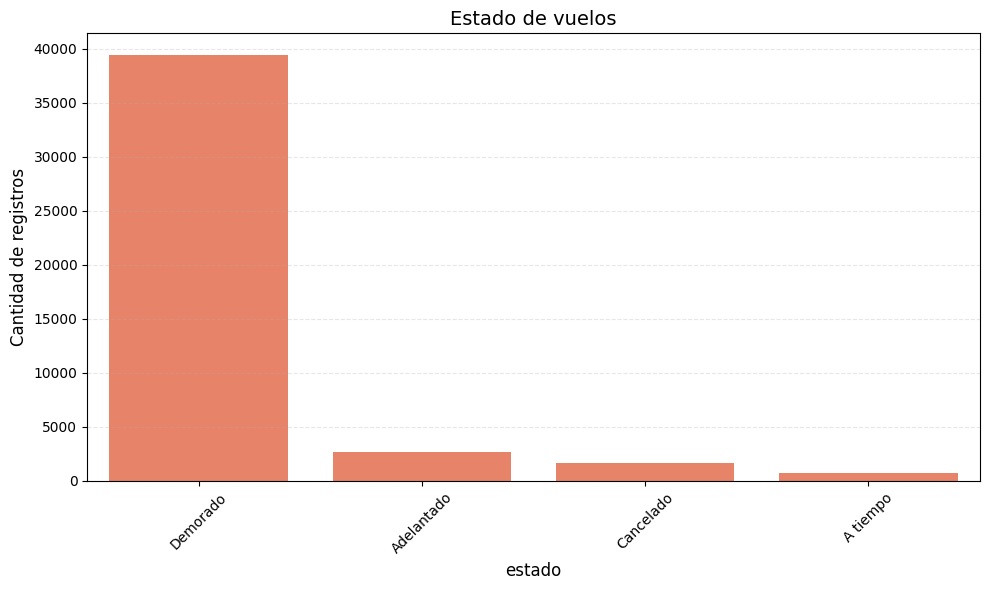

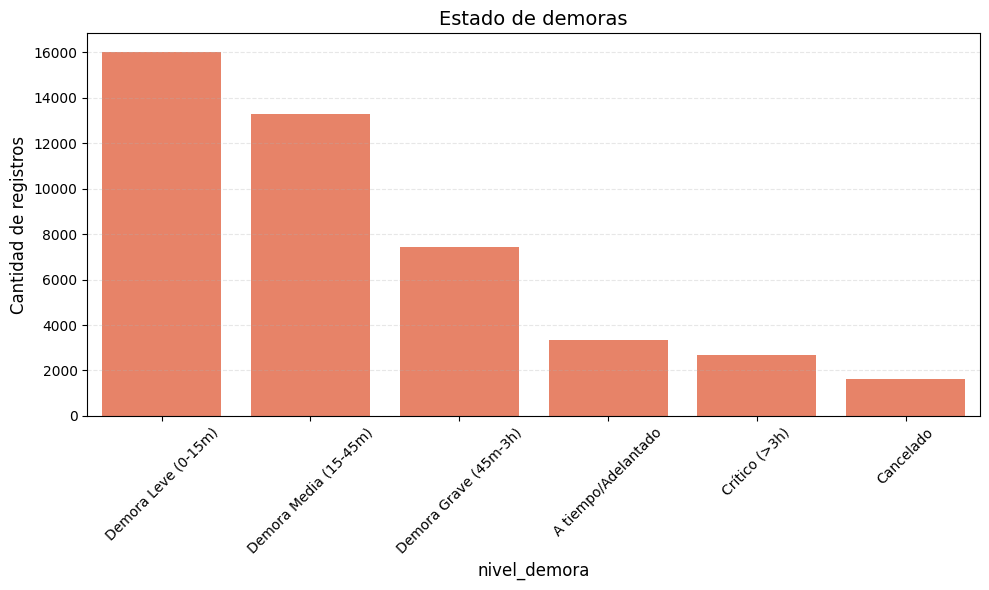

In [6]:
graficar_frecuencias(df, 'estado', color=color_general, titulo='Estado de vuelos')
graficar_frecuencias(df, 'nivel_demora', color=color_general, titulo='Estado de demoras')

Se puede ver que la cantidad de vuelos con demora leve y media supera en gran proporción a los demas vuelos.
También se puede ver que los vuelos cancelados son inferiores a los vuelos con una demora \"Crítico > 3h\"
En el siguiente gráfico veremos como se distribuyen los datos según los minutos de demora.

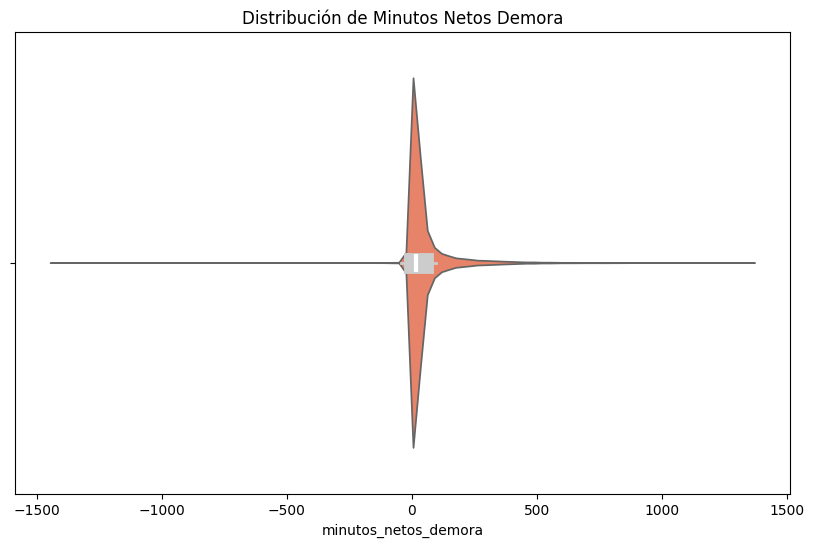

In [7]:
mostrar_distribucion_violin(df, "minutos_netos_demora", color=color_general)

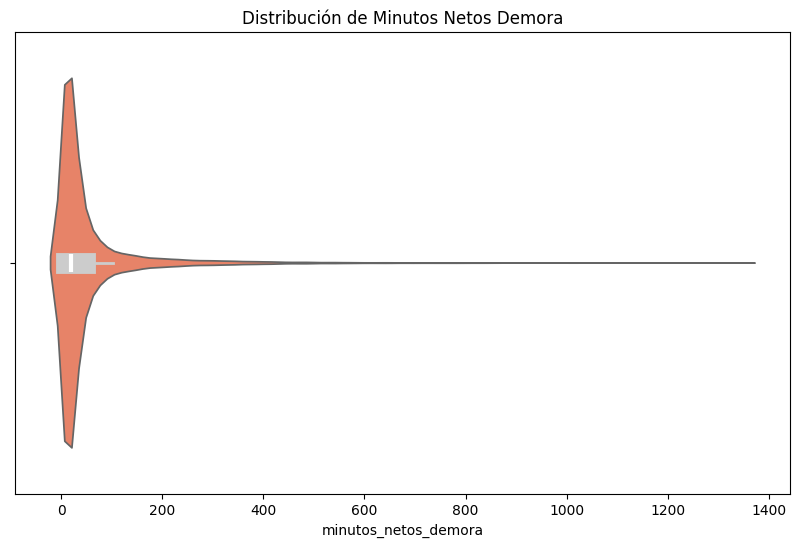

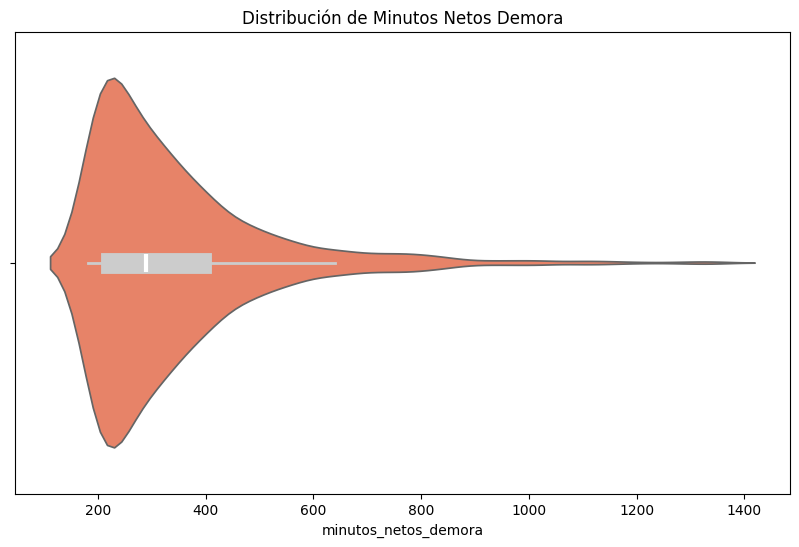

In [8]:
mostrar_distribucion_violin(df, "minutos_netos_demora", valor_minimo=0)
mostrar_distribucion_violin(df, "minutos_netos_demora", valor_minimo=180)

Con el gráfico de violinplot podemos ver cómo se distribuyen los valores de minutos de demora. El valor de 1400 equivalen a más de 23 horas de demora. La mayor concentración se encuentra entre los 0 minutos y los 400 minutos.

## Análisis de Cancelaciones

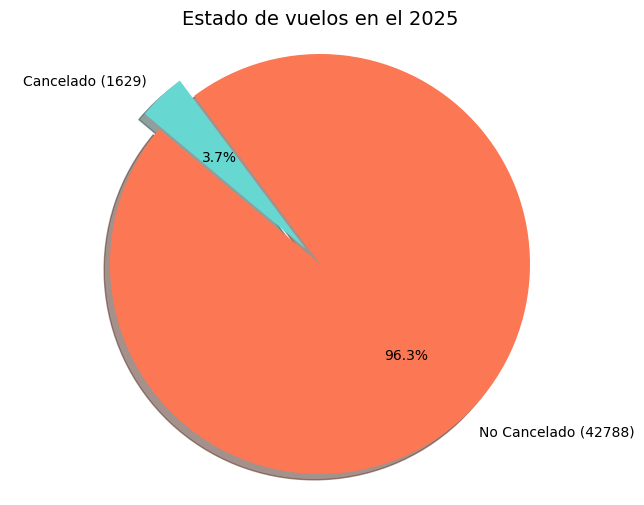

In [9]:
mostrar_torta_personalizada(df, 'esta_cancelado', etiquetas=etiquetas_cancelado, titulo="Estado de vuelos en el 2025", colores=paleta)

La cantidad de vuelos cancelados es mucho menor.

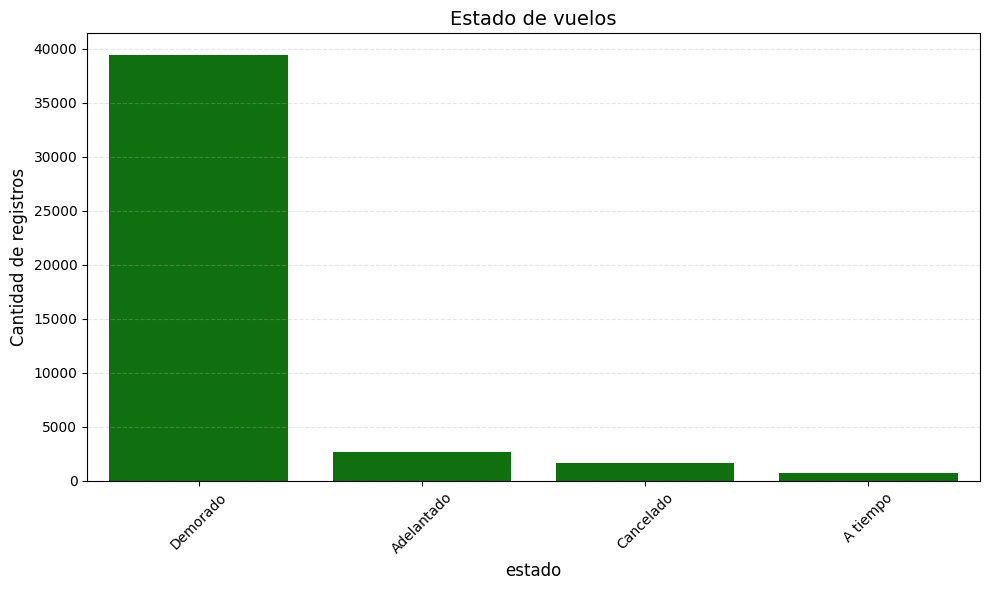

In [10]:
graficar_frecuencias(df, 'estado', titulo='Estado de vuelos')

# Análisis Bivariado
Vamos a comparar las empresas \"Jetsmart\" y \"Flybondi\" como fue su desempeño en vuelos cancelados y con demoras. La evolución de mes a mes.

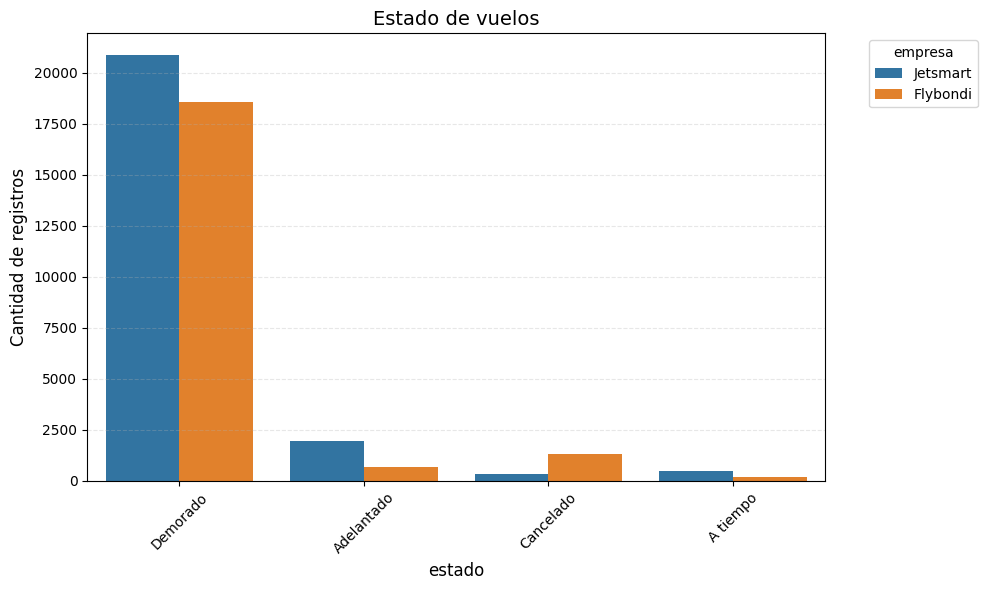

In [11]:
graficar_frecuencias(df, 'estado', categoria="empresa", titulo='Estado de vuelos')

Se puede ver que la empresa Jetsmart posee más retrasos en vuelos, pero en la empresa Flybondi posee mayor cantidad de vuelos cancelados.

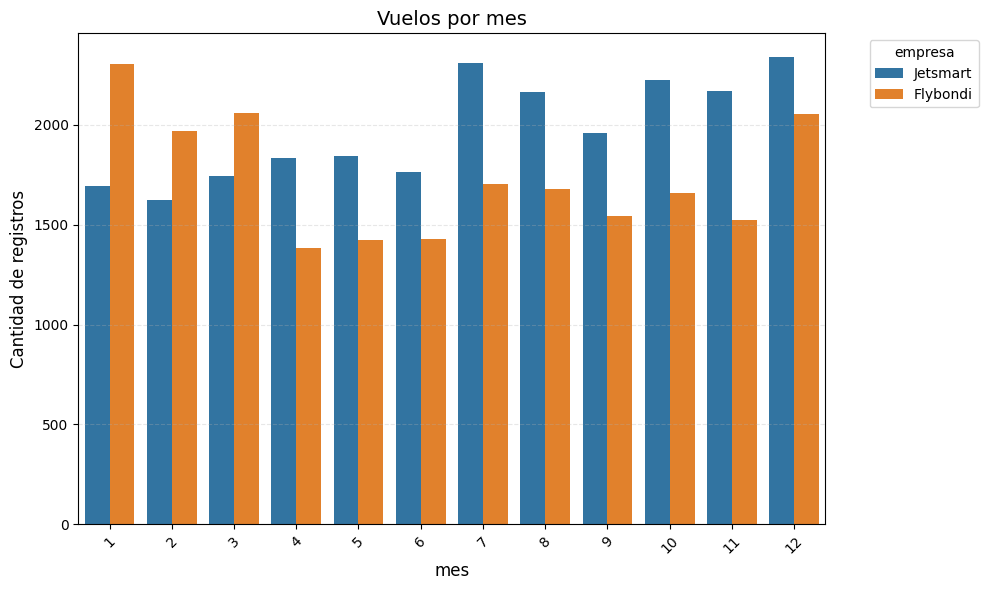

In [12]:
graficar_frecuencias(df, 'mes', categoria="empresa", titulo='Vuelos por mes', ordenar_por_indice=True)

### Demoras de vuelos

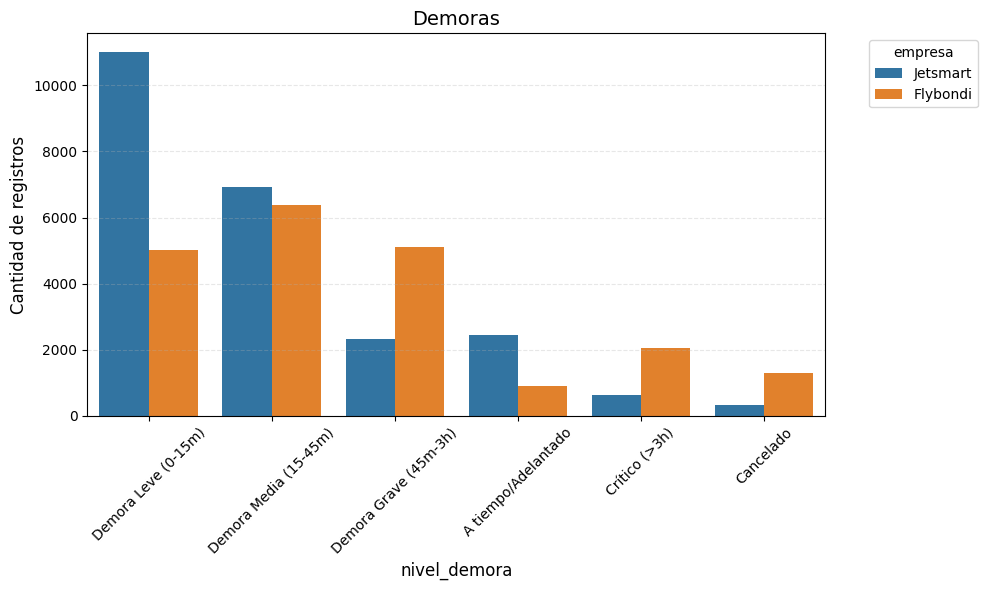

In [13]:
graficar_frecuencias(df, 'nivel_demora', categoria="empresa", titulo='Demoras')

La empresa de \"Jetsmart\" posee mayor cantidad de vuelos con Demora Leve y Demora Media. En cambio las demoras de más de 45 minutos se encuentra liderada por la empresa de Flybondi.

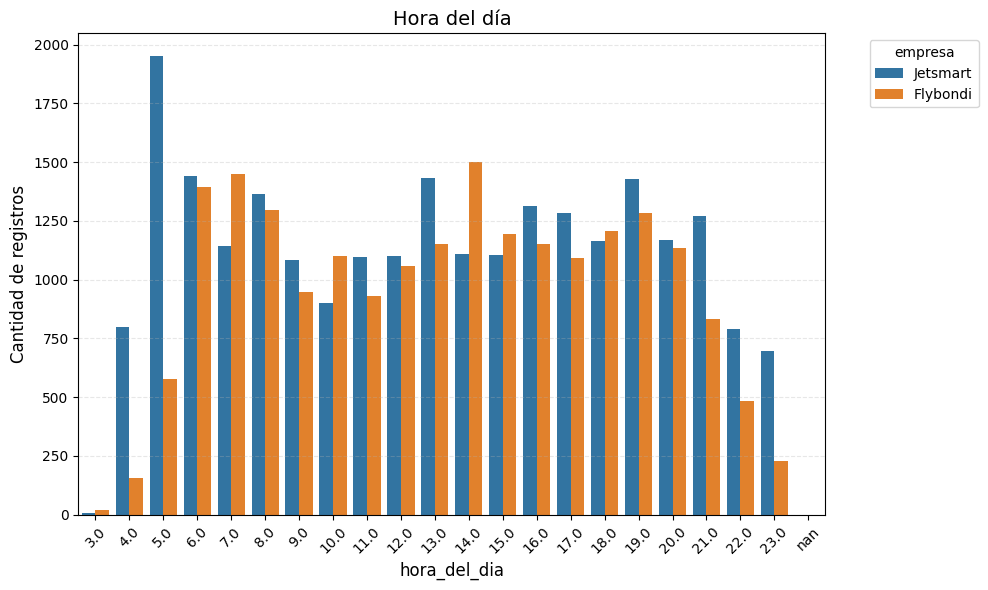

In [14]:
graficar_frecuencias(df, 'hora_del_dia', categoria="empresa", titulo='Hora del día', ordenar_por_indice=True)

A las 5 se encuentra la mayor cantidad de vuelos de la empresa \"Jetsmart\"

# Análisis Multivariado
Vamos a comparar las empresas \"Jetsmart\" y \"Flybondi\" como fue su desempeño en demoras de los vuelos.

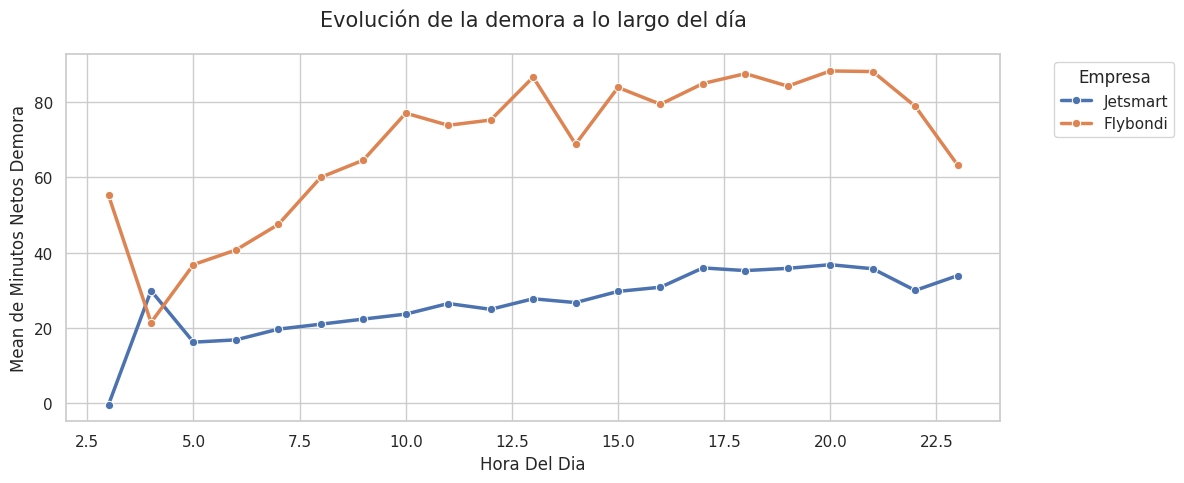

In [15]:
graficar_evolucion(df, 'hora_del_dia', 'minutos_netos_demora', categoria="empresa", estimador='mean', titulo='Evolución de la demora a lo largo del día')

Alrededor de las 4 de la mañana se puede ver en la empresa de Flybondi tiene valores mínimos, ya más adelante la demora sigue creciendo, esto puede deberse a que cada vez se acumulan las demoras. En la empresa de Jetsmart tiene el primer máximo a las 4 am, pero luego se estabiliza esto puede deberse a que las demoras son leves, y no implica mucho retraso en los vuelos siguientes.

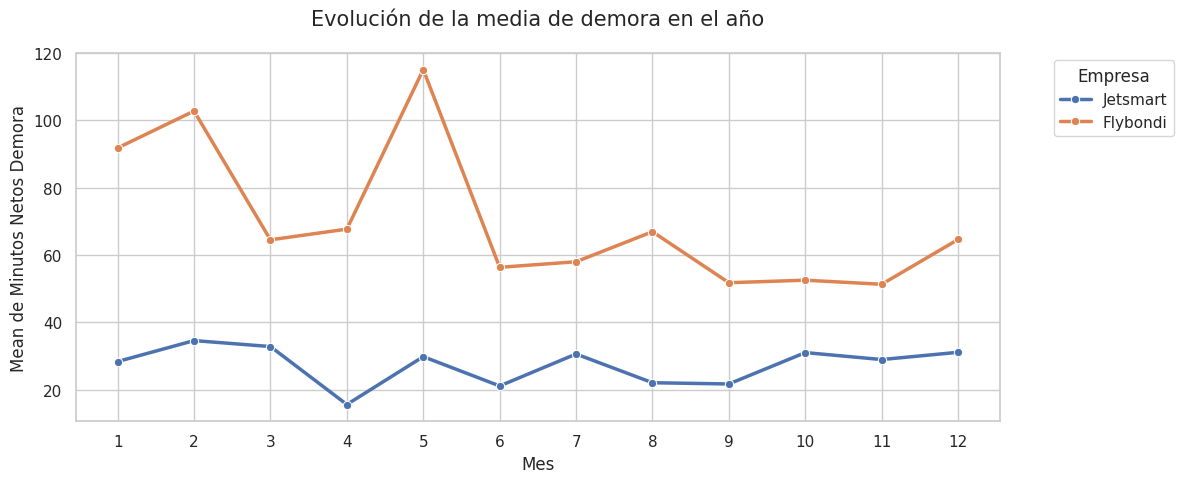

In [16]:
graficar_evolucion(df, 'mes', 'minutos_netos_demora', categoria="empresa", estimador='mean', titulo='Evolución de la media de demora en el año')

Viendo la evolución de la media de minutos de demora se puede ver que en el mes de enero, febrero y Mayo se encuentran los puntos más altos de la empresa de Flybondi.
De la empresa Jetsmart podemos observar que en el mes de abril posee valor mínimo de la media.
Se puede apreciar la diferencia entre las dos empresas, una posee una media de demora mayor. Esta información nos da una idea que al viajar con la primer empresa podremos tener una espera más larga.

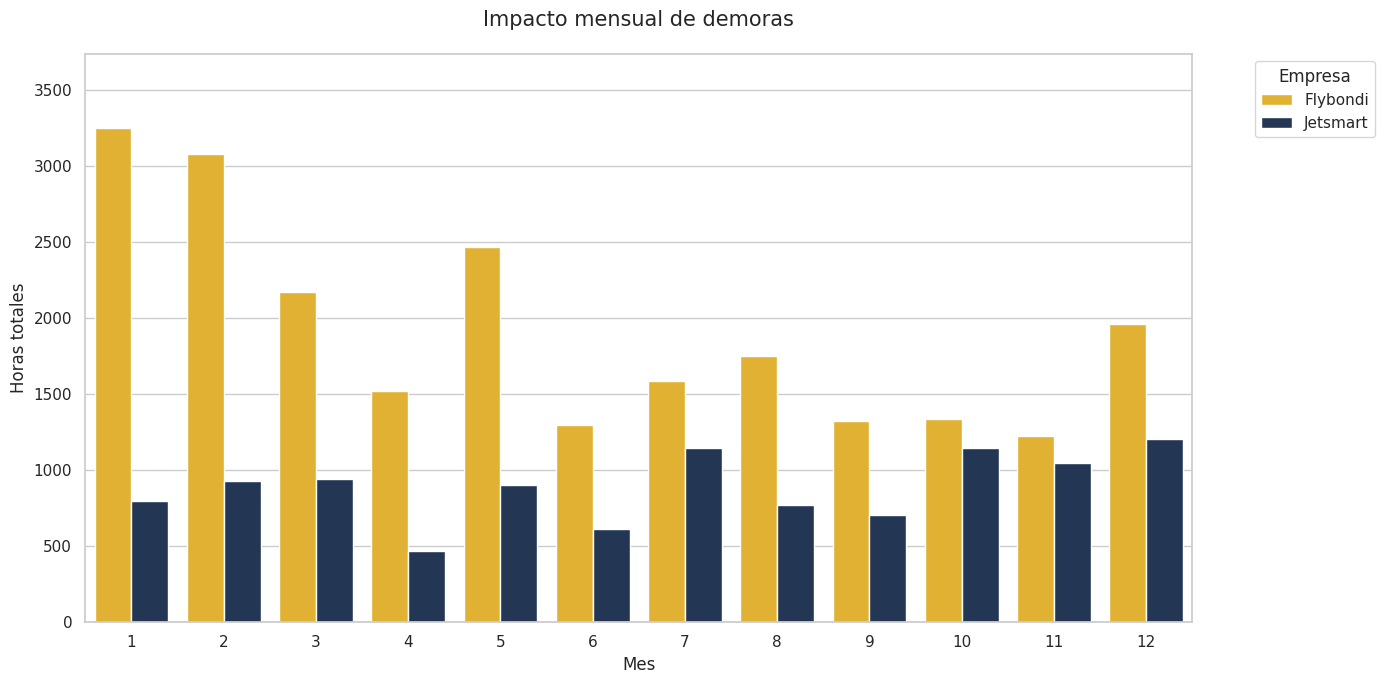

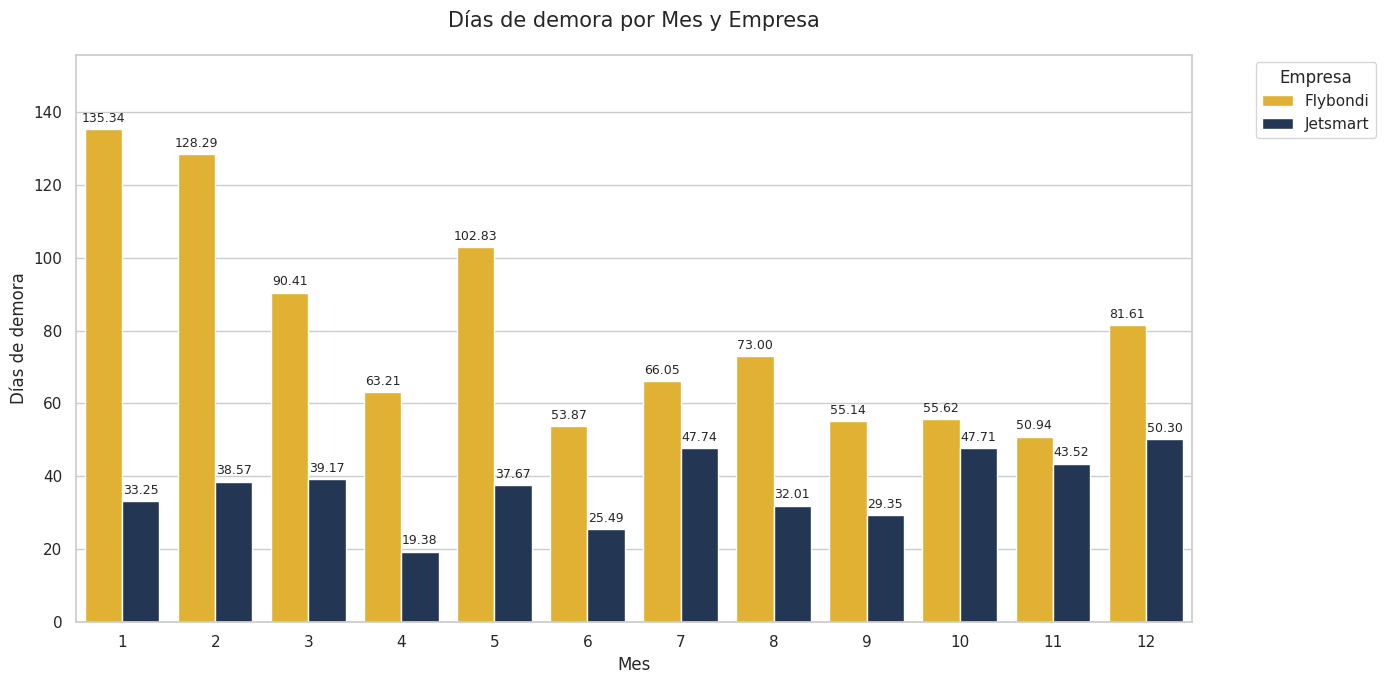

In [17]:
graficar_impacto_temporal(df, titulo="Impacto mensual de demoras", unidad="hours")

# Con otras columnas
graficar_impacto_temporal(df, categoria="empresa", unidad='days', mostrar_etiquetas=True)

El gráfico muestra que los usuarios de Flybondi perdieron mayor tiempo debido a las demoras que los usuarios de Jetsmart. El caso más notable se ve en el mes de enero en el que hay una diferencia equivalente a casi cien días.
Siguiendo con el gráfico de vuelos por mes, la primer empresa tiene mayor volumen de vuelos en los primeros meses. Las demoras pueden ser debido a la gran demanda de pasajes, y al demorarse los vuelos van arrastrando más tiempo de demora.

### Cancelaciones de vuelos

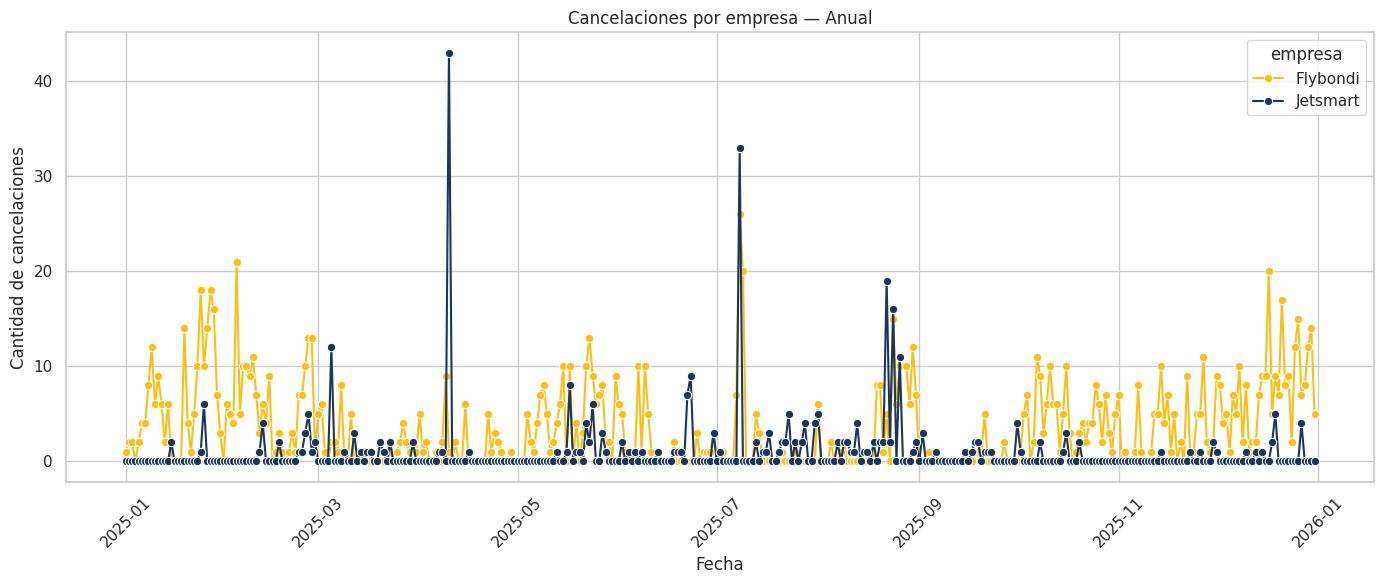

In [18]:
graficar_cancelaciones(df, por_empresa=True)

Podemos visualizar dos picos grandes en el mes de abril y julio. Luego se puede ver que durante los meses de enero, febrero, agosto, noviembre y diciembre hay varios dias con muchas cancelaciones.
Vamos a ver en más detalle mes a mes, primero veremos los picos de cancelaciones y luego aquellos meses con cancelaciones.

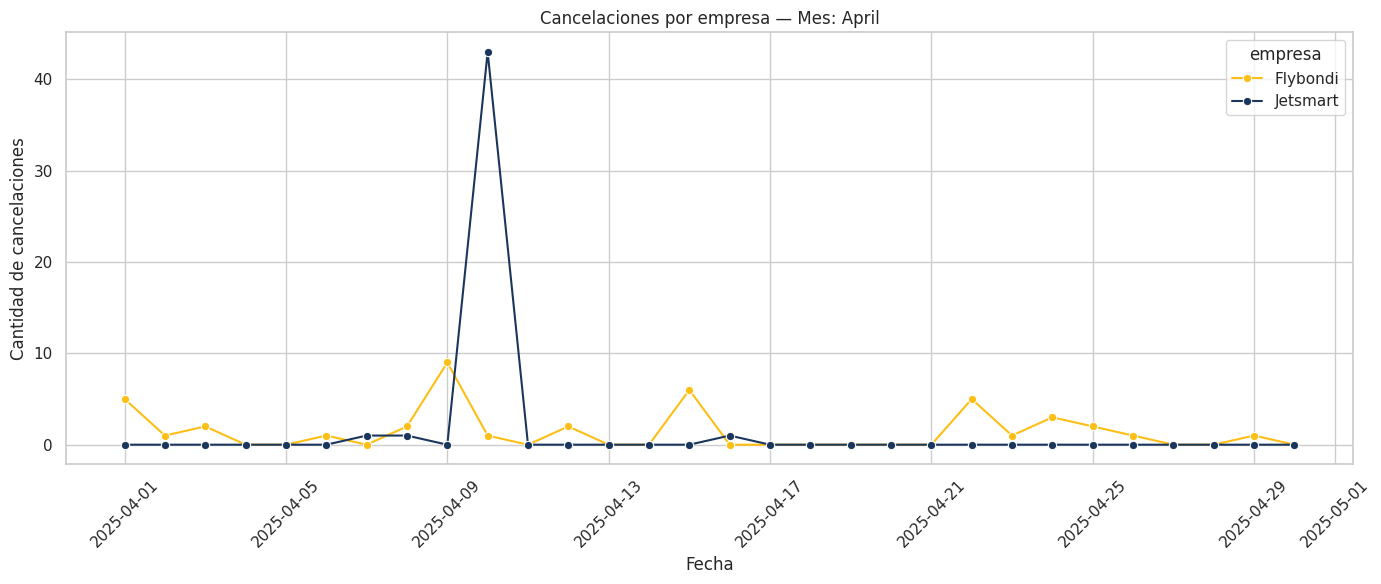

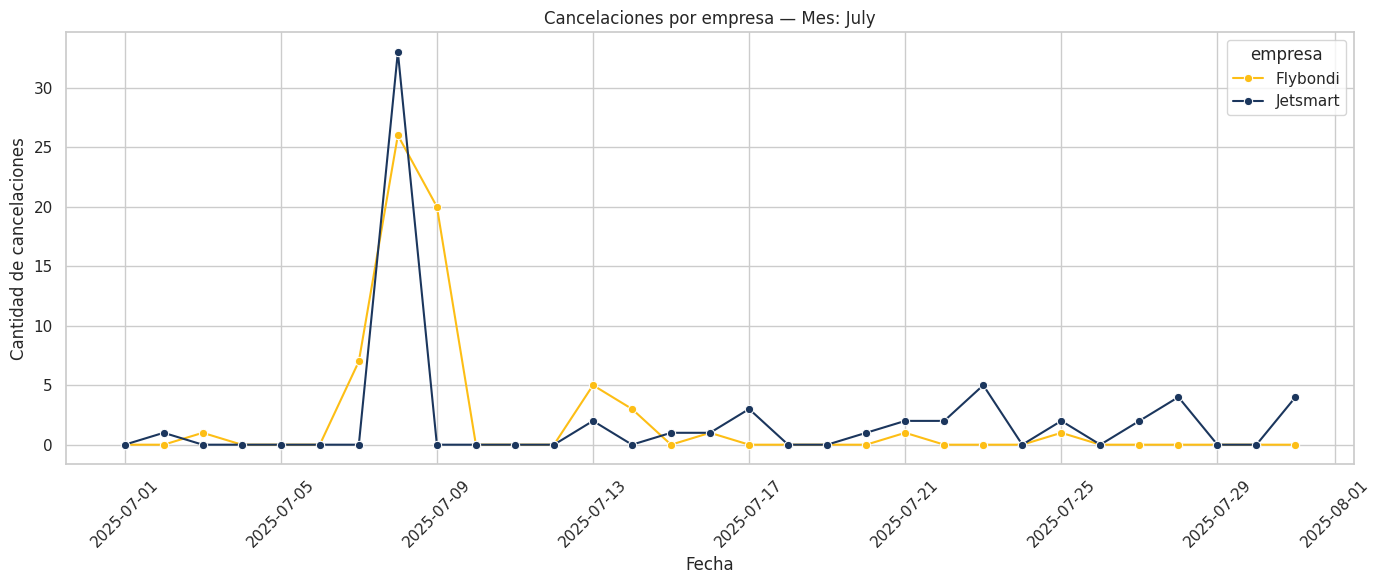

In [19]:
graficar_cancelaciones(df, por_empresa=True, mes=4)
graficar_cancelaciones(df, por_empresa=True, mes=7)

Se puede apreciar que los vuelos del 10 de abril se encuentran un pico de vuelos cancelados.
Buscando más información sobre el estado de los vuelos de esa fecha encontre que hubo un paro general en la Argentina afectando a los vuelos de la empresa.
Link https://www.infobae.com/economia/2025/04/08/paro-general-que-pasara-con-los-vuelos-este-jueves/
El dia 8 de julio las aerolíneas tuvieron que posponer y cancelar muchos vuelos debido a una niebla en los aeropuertos de Buenos Aires.
Este dato es importante a la hora de analizar las cancelaciones de vuelos, no es algo que se pueda preveer con mucha anticipación, siendo julio el mes de vacaciones de invierno la cantidad de vuelos es mayor.

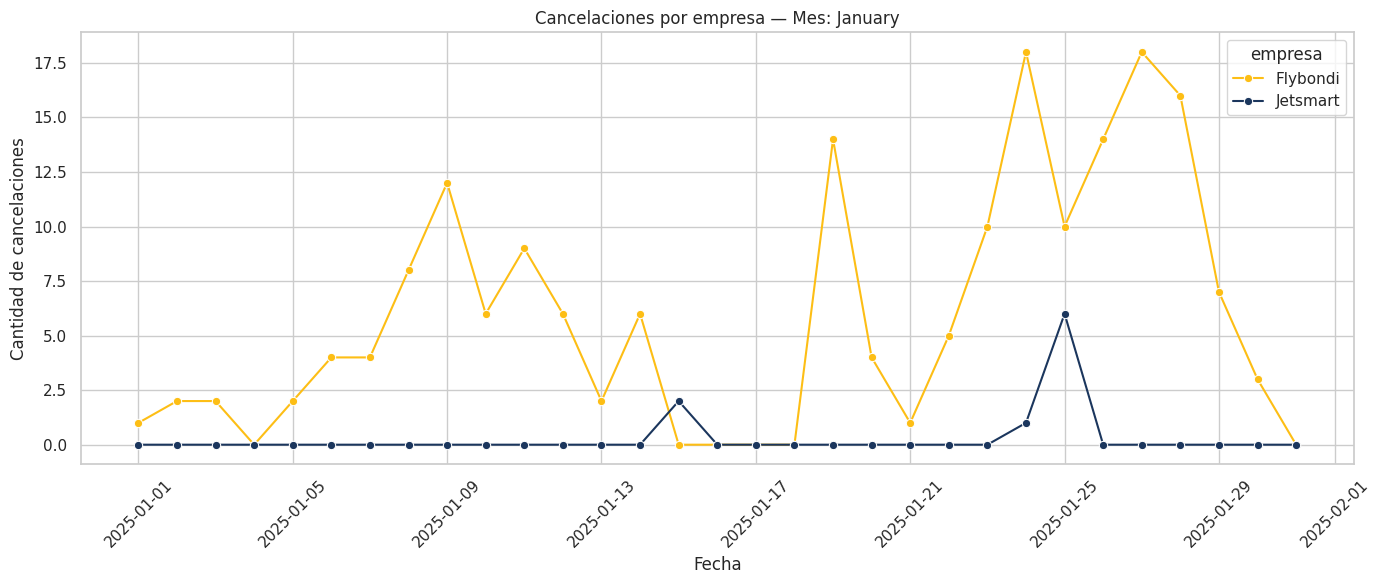

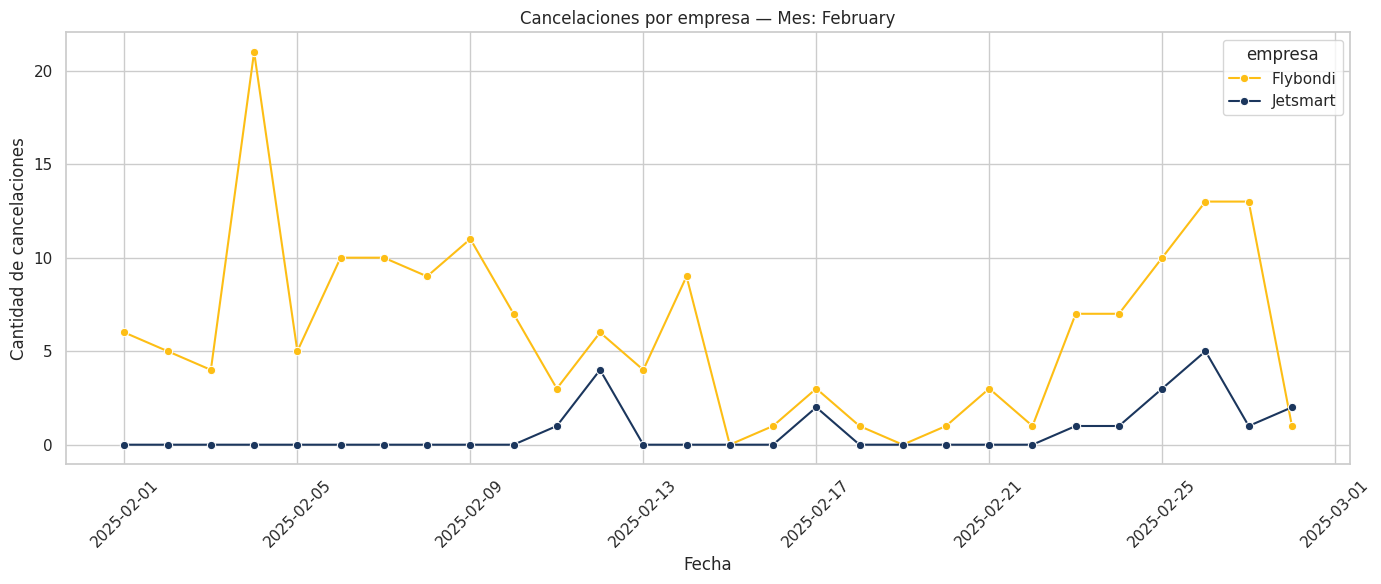

In [20]:
graficar_cancelaciones(df, por_empresa=True, mes=1)
graficar_cancelaciones(df, por_empresa=True, mes=2)

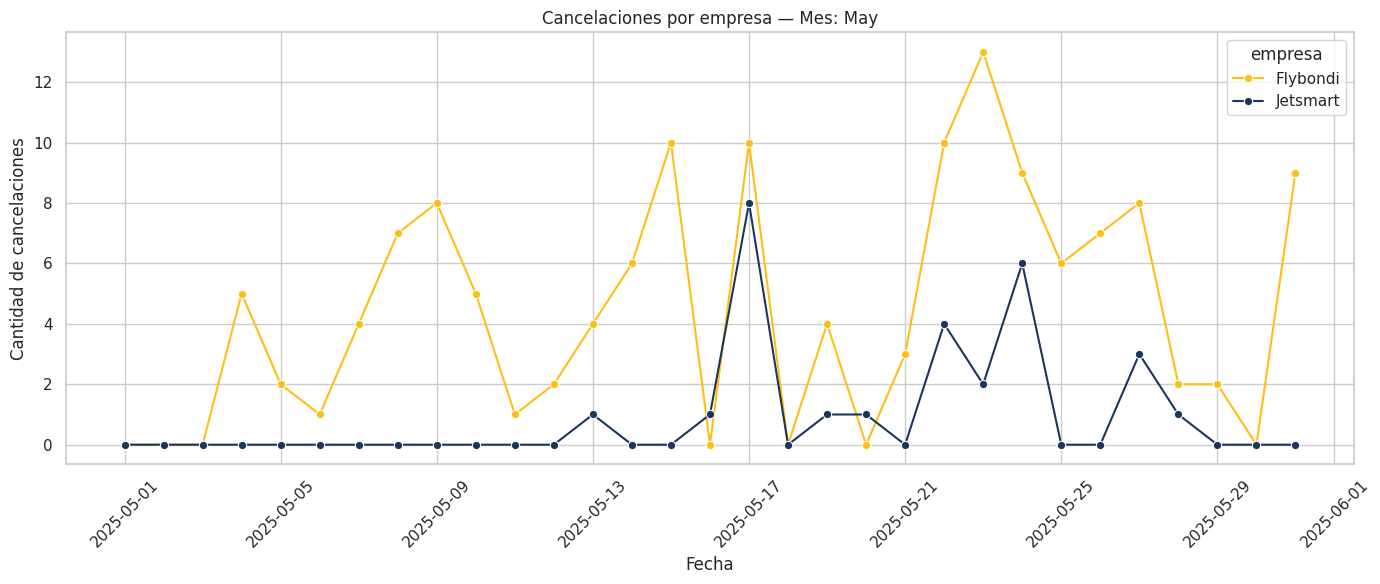

In [21]:
graficar_cancelaciones(df, por_empresa=True, mes=5)

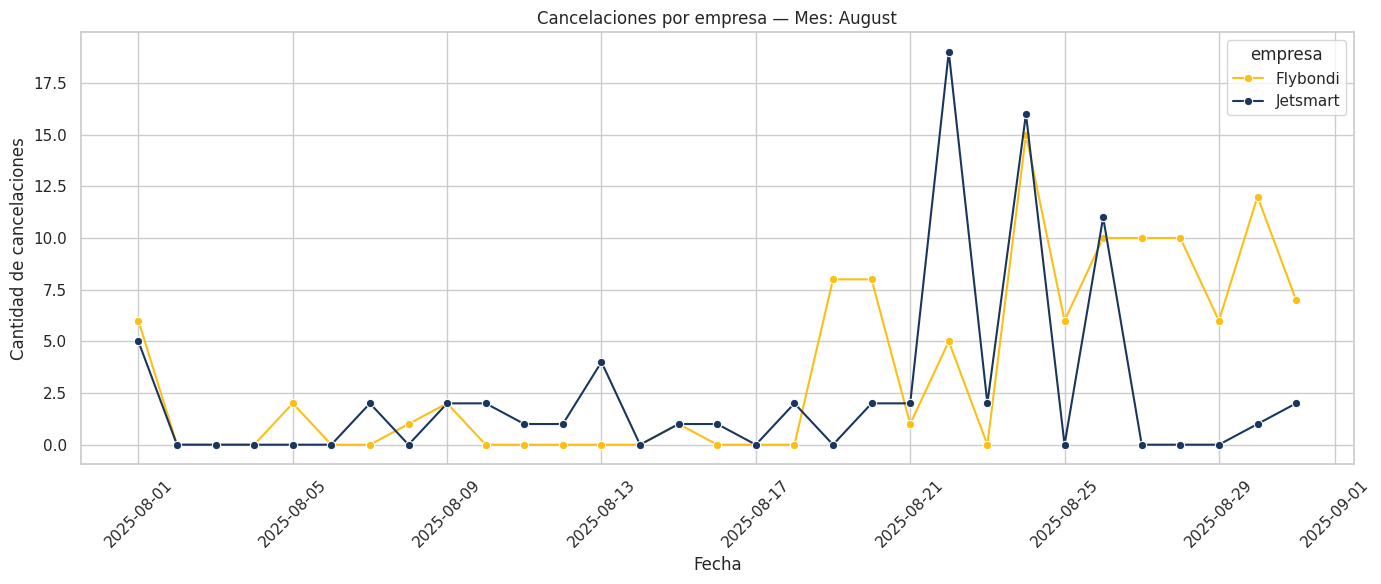

In [22]:
graficar_cancelaciones(df, por_empresa=True, mes=8)

El 22-08 hubo paro de controladores aéreos. https://www.lanacion.com.ar/sociedad/comenzo-el-paro-de-controladores-aereos-en-los-aeropuertos-de-todo-el-pais-nid22082025/

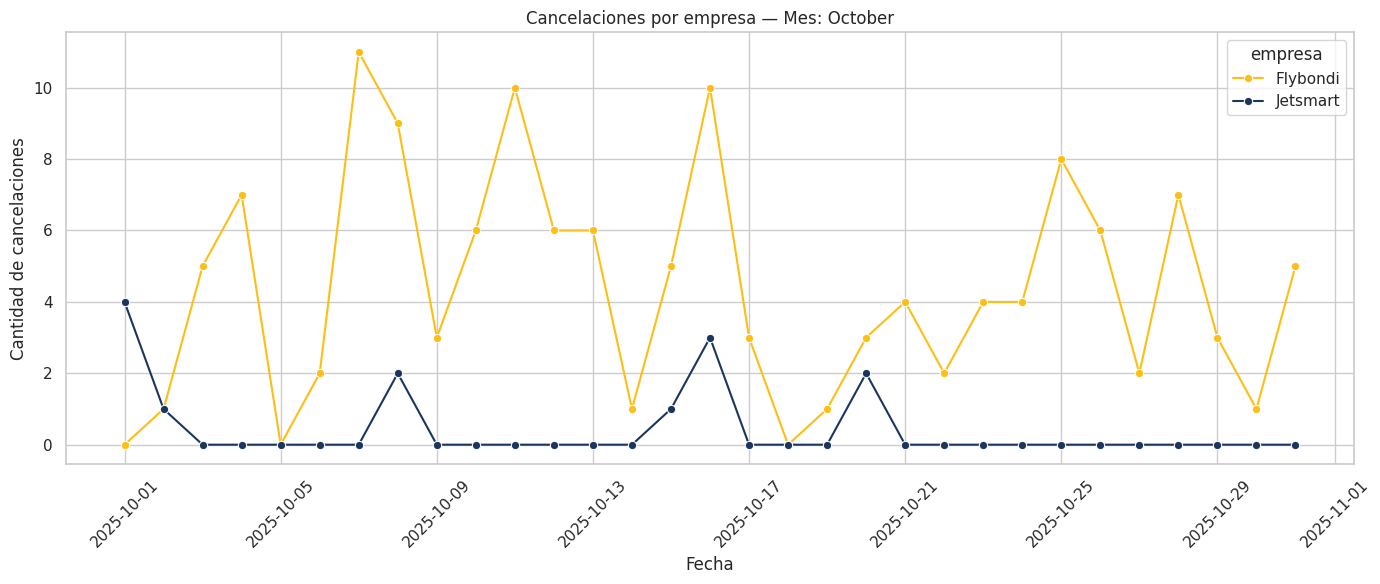

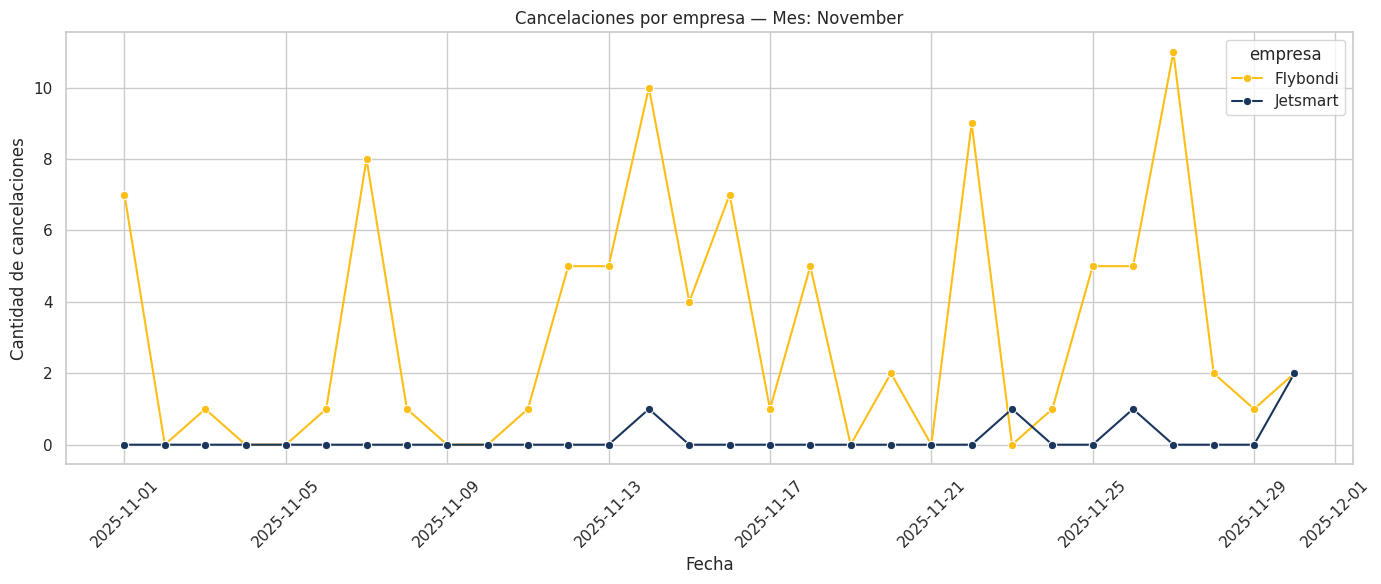

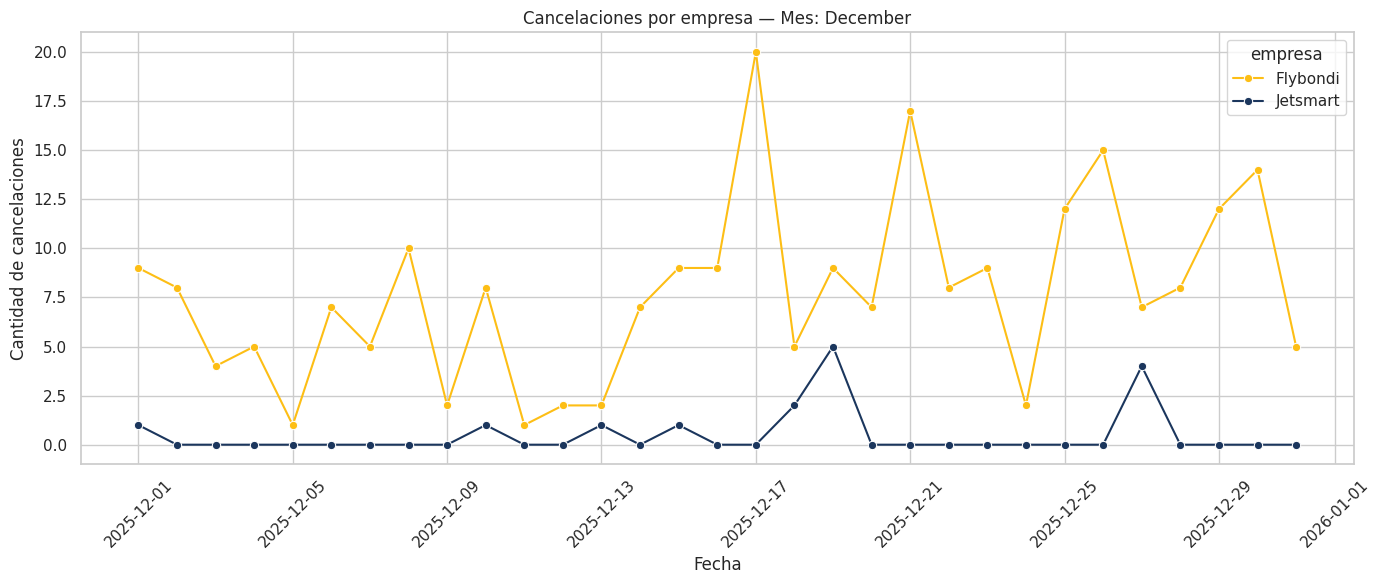

In [23]:
graficar_cancelaciones(df, por_empresa=True, mes=10)
graficar_cancelaciones(df, por_empresa=True, mes=11)
graficar_cancelaciones(df, por_empresa=True, mes=12)

17-12 paro de controladores áereos https://www.pagina12.com.ar/2025/12/17/paro-de-controladores-aereos-demoras-y-reprogramaciones-en-los-vuelos/
En el último trimestre del año 2025 se puede ver que las cancelaciones de Flybondi superan a los de Jetsmart.

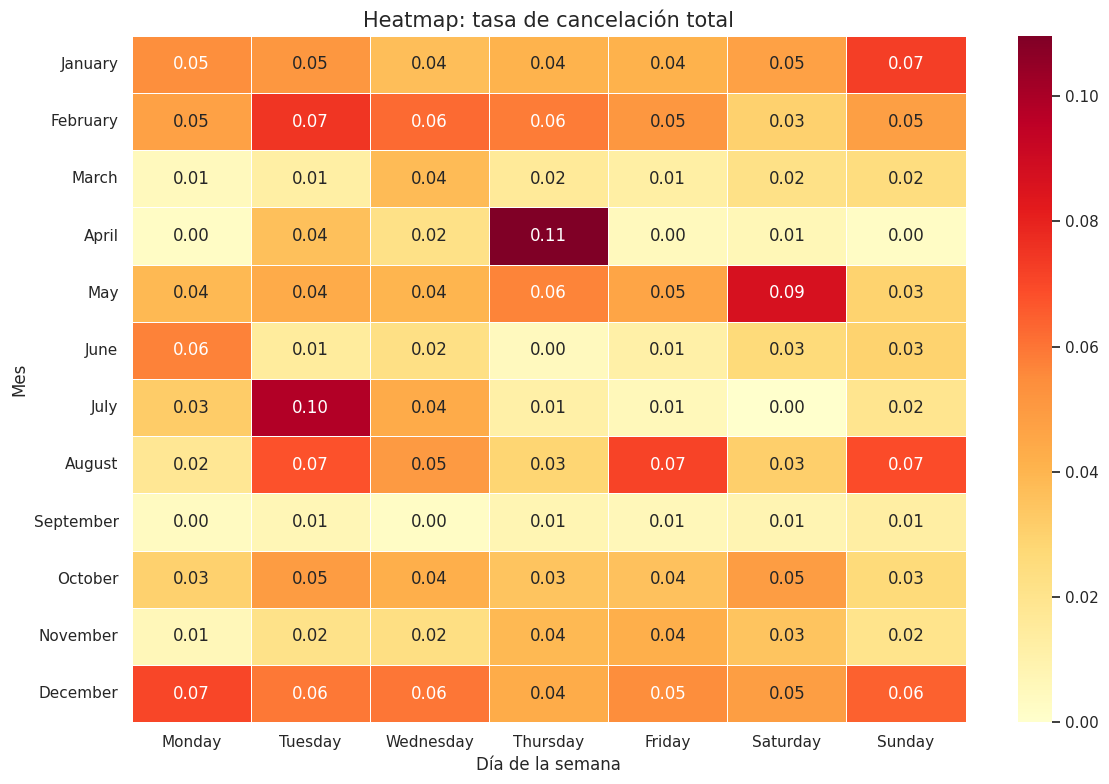

In [24]:
graficar_heatmap_cancelaciones(df)

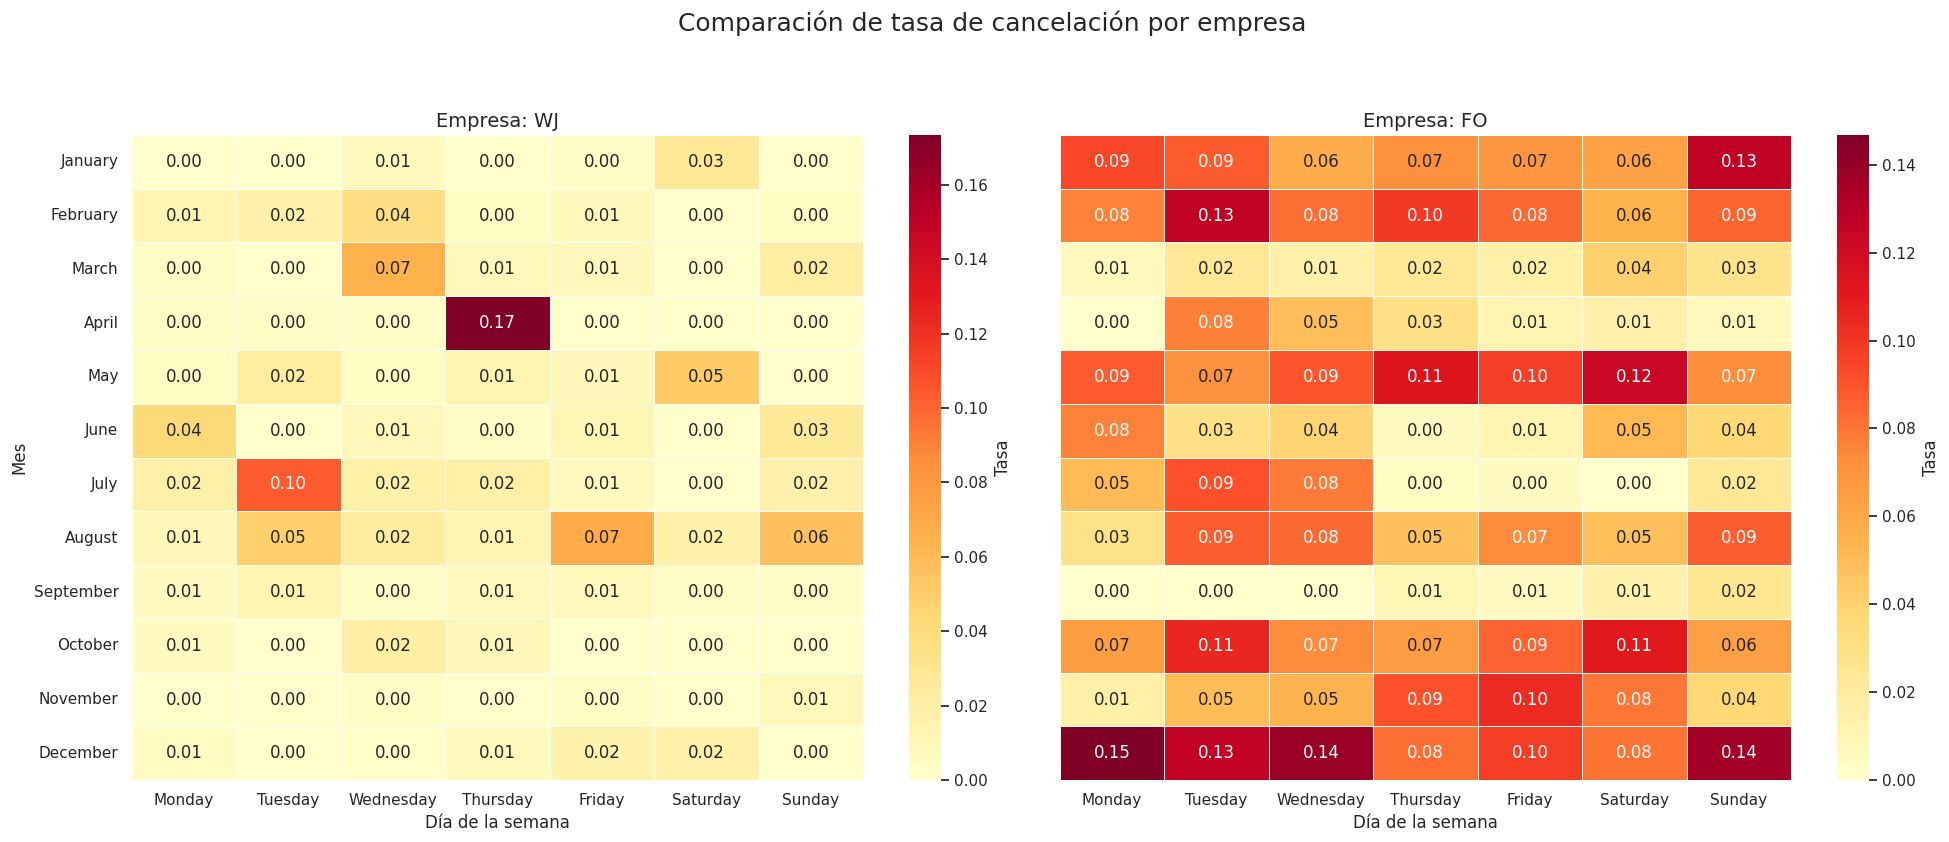

In [25]:
graficar_heatmap_cancelaciones(df, por_empresa=True)

### Reporte final

In [26]:
# 1. Creamos el nuevo dataset agrupado
df_reporte = df.groupby('empresa').agg(
    total_vuelos=('estado', 'count'),
    cancelaciones=('estado', lambda x: (x == 'Cancelado').sum()),
    total_minutos_demora=('minutos_netos_demora', 'sum')
).reset_index()

# 2. Calculamos los días perdidos
# Fórmula: Minutos / 60 (horas) / 24 (día)
df_reporte['dias_perdidos'] = (df_reporte['total_minutos_demora'] / 1440).round(2)

# 3. Opcional: Tasa de cancelación para dar contexto
df_reporte['tasa_cancelacion'] = (df_reporte['cancelaciones'] / df_reporte['total_vuelos'] * 100).round(2)

# Mostramos el resultado
print(df_reporte[['empresa', 'total_vuelos', 'cancelaciones', 'dias_perdidos', 'tasa_cancelacion']])


  empresa  total_vuelos  cancelaciones  dias_perdidos  tasa_cancelacion
0      FO         20742           1287         956.31              6.20
1      WJ         23675            342         444.19              1.44


In [27]:
obtener_reporte_rutas_criticas(df, "FO")


--- REPORTE DE RUTAS CRÍTICAS ---
Filtros -> Empresa: Flybondi | Mes: Todos
Total de rutas analizadas: 73



,total_vuelos,Demora media (min),% Cancelado
Ruta,,,
Mendoza → Córdoba,29,118.2,24.14
Córdoba → Mendoza,30,108.9,23.33
Ezeiza → Posadas,21,73.3,19.05
Aeroparque → Río Gallegos,25,46.8,16.00
Ezeiza → Sao Paulo,32,30.1,12.50
Ezeiza → Neuquen,35,39.4,11.43
Posadas → Aeroparque,475,69.3,11.37
Comodoro Rivadavia → Ezeiza,134,80.5,11.19
Ezeiza → Córdoba,28,57.1,10.71


In [28]:
obtener_reporte_rutas_criticas(df, "WJ")


--- REPORTE DE RUTAS CRÍTICAS ---
Filtros -> Empresa: Jetsmart | Mes: Todos
Total de rutas analizadas: 54



,total_vuelos,Demora media (min),% Cancelado
Ruta,,,
Ezeiza → CPC,13,9.6,7.69
Ezeiza → Florianopolis,49,35.8,4.08
Córdoba → Ezeiza,32,53.8,3.12
Iguazú → Ezeiza,589,33.5,2.72
Salta → Mendoza,270,22.8,2.59
Córdoba → Aeroparque,1371,25.6,2.41
Ezeiza → Bariloche,795,25.0,2.26
Mendoza → Ezeiza,317,29.1,2.21
Ezeiza → SCL,91,33.9,2.20


In [29]:
mes_seleccionado = 12  #@param ["1","2","3","4","5","6","7","8","9","10","11","12"] {type:"raw"}

print("Flybondi:")
obtener_reporte_rutas_criticas(df, "FO", mes=mes_seleccionado)

print("\nJetsmart:")
obtener_reporte_rutas_criticas(df, "WJ", mes=mes_seleccionado)


Flybondi:

--- REPORTE DE RUTAS CRÍTICAS ---
Filtros -> Empresa: Flybondi | Mes: December
Total de rutas analizadas: 54


Jetsmart:

--- REPORTE DE RUTAS CRÍTICAS ---
Filtros -> Empresa: Jetsmart | Mes: December
Total de rutas analizadas: 47



,total_vuelos,Demora media (min),% Cancelado
Ruta,,,
Aeroparque → REL,21,31.2,4.76
Ezeiza → Salta,30,20.1,3.33
Aeroparque → SCL,65,25.9,3.08
Córdoba → Aeroparque,131,30.7,2.29
Ezeiza → Mendoza,56,29.9,1.79
Aeroparque → Córdoba,131,27.8,1.53
Ezeiza → Iguazú,71,32.1,1.41
Bariloche → Ezeiza,72,38.1,1.39
Ezeiza → Bariloche,82,29.4,1.22


## Conclusión
Luego de analizar los vuelos del dataset, y ver que dias hubieron mayor cantidad de cancelaciones y buscar el motivo, hay algo que no se estaba considerando en el dataset para el próximo paso que es el de paro de trabajadores del sector aeropuertario.
Se debe trabajar con esa información para que un modelo predictivo sea eficiente, para esto voy a sumar la columna flag es_paro con valores booleanos.